In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from shared.cpcrr.methods.cokrigingfitter import CoKrigingFitter
from shared.cpcrr.functions import onevar, onevarAD
from shared.sample_funcs import peaks, peaksAD
from shared.sampling import random_latin_hypercube, space_filling_latin_hypercube, find_subset, align_subset

Done.
µ -3.435566222847853 σ2 26.936024080388496
θ [16.89778449]
θd [0.001]
rho 1.9997101385159124
globmean -3.435566222847853
globmeand 12.21423213040486
globvar 26.936024080388496
globvard 49445.92997996034


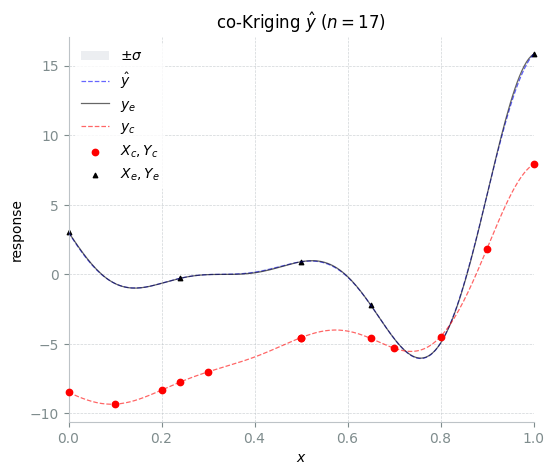

In [8]:
x_c = np.array([
    0,
    0.24,
    0.5,
    0.65,
    1.0,
    0.1,
    0.2,
    0.3,
    0.5,
    0.7,
    0.8,
    0.9
])
y_c = onevarAD(x_c)
nlow = x_c.shape[0]

x_e = datax = np.array([
    0.0,
    0.24,
    0.5,
    0.65,
    # 0.82,
    # 0.9,
    1.0,
])
y_e = onevar(x_e)

datax = np.concatenate([x_c, x_e])
datay = np.concatenate([y_c, y_e])

if len(datax.shape) == 1:
    datax = datax.reshape(-1,1)


CKF = CoKrigingFitter(
    xmin=(0,),
    xmax=(1,),
    datax=datax,
    datay=datay,
    nlow=nlow
)


# CKF.plot_check_inputs(objective=onevar)


CKF.fit(
    # verbose=True,
)


print("Done.")
print(f"µ {CKF.globmean} σ2 {CKF.globvar}")
print(f"θ {CKF.theta}")
print(f"θd {CKF.thetad}")
print(f"rho {CKF.rho}")
print(f"globmean {CKF.globmean}")
print(f"globmeand {CKF.globmeand}")
print(f"globvar {CKF.globvar}")
print(f"globvard {CKF.globvard}")

CKF.plot_check_model(objective_e=onevar, objective_c=onevarAD,res=200)

/home/ian/code/rceu-2026/src/shared/sampling.py:84: RuntimeWarning: divide by zero encountered in divide
  return sum(((J/(d**q))**(1/q)))


ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
ILL CONDITIONED cheap
Done.
µ -0.7455788499408335 σ2 3.2990246301103885
θ [0.97839645 1.14939985]
θd [ 3.57025129 31.33888288]
rho 0.9999999998011249
globmean -0.7455788499408335
globmeand 0.999999999866459
globvar 3.2990246301103885
globvard 6.725003132019145e-20


<Figure size 600x500 with 0 Axes>

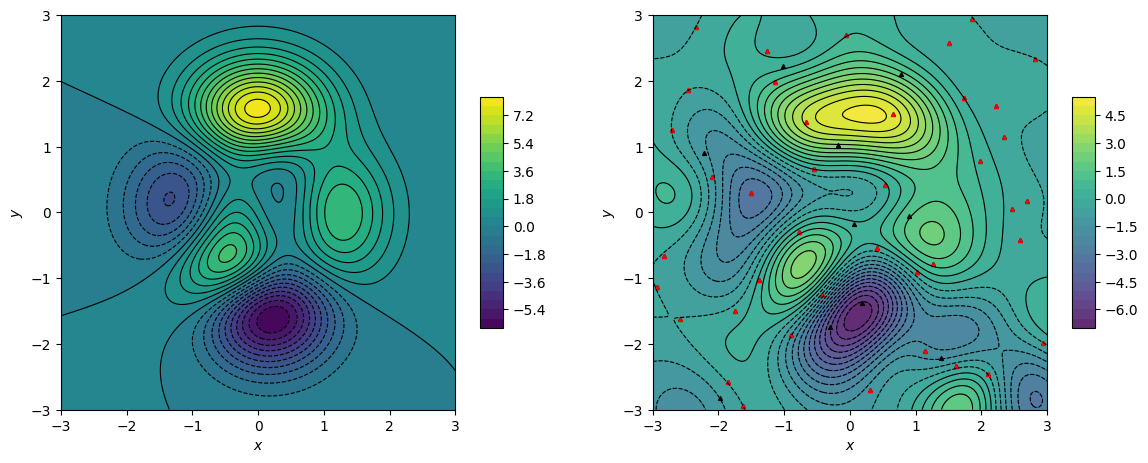

In [ ]:
nlow = 50
nhigh = 40
k = 2

X_rlhc = random_latin_hypercube(nlow, k, [-3,-3],[3,3])
X_sample,q,_ = space_filling_latin_hypercube(X_rlhc)

subset = find_subset(X_sample, nhigh, q)
datax  = align_subset(X_sample,subset)

x_c = datax[:nlow]
x_e = datax[:nhigh]

y_c = peaksAD(x_c)
y_e = peaks(x_e)

datay = np.concatenate([y_c, y_e])


CKF = CoKrigingFitter(
    xmin=(-3,-3),
    xmax=(3,3),
    datax=datax,
    datay=datay,
    nlow=nlow,
    ill_conditioned=-100
)

CKF.fit(
    # verbose=True,
)


print("Done.")
print(f"µ {CKF.globmean} σ2 {CKF.globvar}")
print(f"θ {CKF.theta}")
print(f"θd {CKF.thetad}")
print(f"rho {CKF.rho}")
print(f"globmean {CKF.globmean}")
print(f"globmeand {CKF.globmeand}")
print(f"globvar {CKF.globvar}")
print(f"globvard {CKF.globvard}")

CKF.plot_check_model(objective_e=peaks, res=200)

Text(0.5, 1.0, '$\\hat{f}(x,y)$)')

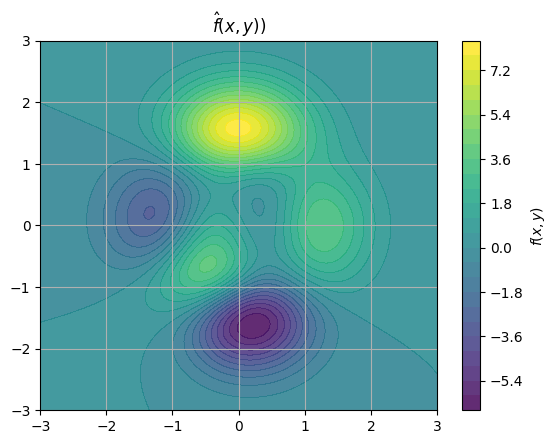

In [ ]:
Nside = 200
x = np.linspace(-3, 3, Nside)
y = np.linspace(-3, 3, Nside)
X, Y = np.meshgrid(x, y)
matr = np.hstack((X.reshape((-1, 1)), Y.reshape((-1, 1))))
Z_true = peaks(matr).reshape((Nside, Nside))


vmin, vmax = Z_true.min(), Z_true.max()
norm = Normalize(vmin=vmin, vmax=vmax)


contour = plt.contourf(X, Y, Z_true, levels=24, cmap='viridis', norm=norm, alpha=0.85)
# plot collocation points used to perform model fit

plt.colorbar(contour, label='$f(x,y)$')
plt.grid(True)
plt.title(rf"$\hat{{f}}(x,y)$)")